# Implementacão - Multiprocessing

## Detalhes

1. Mutiprocessing utilzia fork() (no Linux). O processo filho nasce como uma cópia exata da memória do pai.

2. Copy-on-Write (fork)
- Ao utilizar *multiprocessing* os dados não são copiados; o filho herda a memória. Assim, o custo de transferência de dados é praticamente zero.
- Multiprocessing utiliza variáveis globais (como A_global) que já estão na memória do filho sem custo de cópia ("Zero-copy" via Copy-on-Write).



## Execução do Jupyer Notebook

### Comando Bash

```bash
pyenv global 3.12.12
pyenv shell 3.12.12

OMP_NUM_THREADS=1 MKL_NUM_THREADS=1 VECLIB_MAXIMUM_THREADS=1 OPENBLAS_NUM_THREADS=1 NUMEXPR_NUM_THREADS=1 jupyter notebook
```

## Confirmação de versão do Python em uso

In [1]:
import sys
print(sys.version_info)

sys.version_info(major=3, minor=14, micro=0, releaselevel='final', serial=0)


In [ ]:
## Testes

CPU_SETS = {
    "1-T": [0],
    "2-T": [0, 2],
    "2-T-HP": [0, 1],
    "4-T": [0, 2, 4, 6],
    "4-T-HP": [0, 1, 2, 3],
    "8-T": [0, 2, 4, 6, 8, 10, 12, 14],
    "8-T-HP": [0, 1, 2, 3, 4, 5,6,7],    
}

# Script multiprocessing sem carregar do arquivo

In [5]:
import multiprocessing as mp
import psutil
import getpass
import os
import sys
import time
import numpy as np
import pandas as pd
from datetime import datetime

# -----------------------------------------------------------------------
# Parâmetros experimentais

# Projeto experimental: 'experiments_plan.csv'

MATRIX_SIZE = 1000 # size of NxN matrices

CPU_SETS = {   
    "8P_HT_OFF": [0, 2, 4, 6, 8, 10, 12, 14], # p-cores (8 cores, 1 thread per core)
    "4P_HT_ON": [0, 1, 2, 3, 4, 5, 6, 7], # p-cores (4 cores, 2 threads per core)
    "4P_4E_HT_OFF": [0, 2, 4, 6, 16, 17, 18, 19], # p-cores e e-cores (4 cores p-core, 4 cores e-core)
    "8E": [16, 17, 18, 19, 20, 21, 22, 23] # e-cores (8 cores, 1 thread per core)
}

NUM_RUNS = 10 # runs per CPU set

GOVERNOR = "performance"
IDLE_TIME = 10 # segundos entre execuções

# Variáveis globais (matrizes) para serem herdadas pelos workers
A_global = None
B_global = None

# -----------------------------------------------------------------------
# Safety check
def safety_check(cpu_ids):
    if MATRIX_SIZE % len(cpu_ids) != 0:
        print(f"Error: MATRIX_SIZE ({MATRIX_SIZE}) is not divisible by number of workers ({len(cpu_ids)}).")
        sys.exit(1)

# --------------------------------------
# Governor configuration
def set_governor(governor: str):
    """
    Altera o CPU governor de todos os núcleos para o valor especificado.

    Parâmetros:
        governor (str): nome do governor (ex.: "performance", "powersave", "schedutil").
    """
    password = getpass.getpass("Sudo password: ")

    # Interpolamos o valor do parâmetro governor dirTempetamente no comando bash
    bash_command = f"""
    for cpu_file in $(ls -v /sys/devices/system/cpu/cpu*/cpufreq/scaling_governor); do
        cpu_name=$(basename $(dirname $(dirname $cpu_file)))
        
        echo "{governor}" | sudo tee $cpu_file > /dev/null
        
        current_gov=$(cat $cpu_file)
        #echo "$cpu_name: $current_gov"
    done
    """

    # Usa sudo -S para aceitar senha via stdin
    command = f'echo "{password}" | sudo -S bash -c \'{bash_command}\''
    os.system(command)    
        
# --------------------------------------
# Governor detection
def get_governor(cpu_id):
    path = f"/sys/devices/system/cpu/cpu{cpu_id}/cpufreq/scaling_governor"
    try:
        with open(path) as f:
            return f.read().strip()
    except FileNotFoundError:
        return "N/A"

# Worker task: Acessa as matrizes globais
def worker_task_global(args):
    row_index, chunk_size, cpu_ids = args
    worker_id = row_index // chunk_size # Calcula um ID simples para o worker
    
    # Define a afinidade
    p = psutil.Process(os.getpid())
    p.cpu_affinity([cpu_ids[worker_id]])
    
    # Pega o chunk da matriz A global
    start_row = row_index
    end_row = row_index + chunk_size
    A_chunk = A_global[start_row:end_row, :]
    
    # Calcula usando a matriz B global (que foi herdada, não copiada)
    return np.dot(A_chunk, B_global)

# --------------------------------------
# Main execution loop
if __name__ == "__main__":
    
    print("Passo 1: Configurar governor")
    set_governor(GOVERNOR)
    
    results = []  # lista para armazenar resultados      
    
    # Inicializa as matrizes globais
    A_global = np.random.rand(MATRIX_SIZE, MATRIX_SIZE).astype(np.float64)
    B_global = np.random.rand(MATRIX_SIZE, MATRIX_SIZE).astype(np.float64)
    
    print("Passo 2: Execuções")
    for run in range(1, NUM_RUNS + 1):        
        for label, cores in CPU_SETS.items():
            # Garantir que o workload será dividido igualmente
            safety_check(cores)
            
            # Garantir que o governor está correto
            governor = get_governor(cores[0])

            # Split A into chunks by rows
            chunk_size = MATRIX_SIZE // len(cores)
            
            # Tarefas agora contêm apenas índices, muito leves
            tasks = [(i*chunk_size, chunk_size, cores) for i in range(len(cores))]

            start_time = time.time()
            
            # Criação do pool. Matrizes herdadas por fork()
            with mp.Pool(processes=len(cores)) as pool:
                C_chunks = pool.map(worker_task_global, tasks)
            
            # Combinação de resultados
            C = np.vstack(C_chunks)
            
            end_time = time.time()
            total_time = end_time - start_time
            
            # Validação de resultados
            #C_reference = np.matmul(A_global, B_global)
            #is_match = np.allclose(C, C_reference)
            #validacao_ok = "OK" if is_match else "FAIL"
            #print(f"  -> Validação: {validacao_ok}")
            
            # salva os dados em um dataFrame
            results.append({
                "Run": run,
                "Scenario": label,
                "CPUs_used": cores,
                "Governor": governor,
                "Time_sec": total_time,
                "Result_shape": C.shape
            })
            
            print(f"Run {run} | Time: {total_time:.4f}s | Governor: {governor} | {label}: {cores}")

            # Idle para estabilizar
            #print(f"Aguardando {IDLE_TIME} segundos para estabilização...\n")
            time.sleep(IDLE_TIME)
            
    # cria dataframe com todos os resultados
    df_results = pd.DataFrame(results)
    pd.set_option('display.width', 1000) # Evita quebra de linha do print do df  
    df_reduced = df_results[["Run", "Scenario", "Governor", "Time_sec"]]
    df_sorted = df_reduced.sort_values(by="Scenario", ascending=False)
    print("\nResumo em DataFrame:\n", df_sorted)
    
    # salvar em CSV
    now = datetime.now()
    data_str = now.strftime("%Y%m%d") # formato aaaammdd
    hora_str = now.strftime("%H%M%S") # formato hhmmss
    filename = (
    f"experimentos01-multiprocessing/{data_str}_{hora_str}_matrix{MATRIX_SIZE}_"
        f"numruns{NUM_RUNS}_{GOVERNOR}.csv"
    )
    df_results.to_csv(filename, index=False)
    print(f"\nResultados salvos em: {filename}")           
            

Passo 1: Configurar governor
Sudo password: ········


[sudo] senha para jgross: 

Passo 2: Execuções
Run 1 | Time: 0.0962s | Governor: performance | 8P_HT_OFF: [0, 2, 4, 6, 8, 10, 12, 14]
Run 1 | Time: 0.1173s | Governor: performance | 4P_HT_ON: [0, 1, 2, 3, 4, 5, 6, 7]
Run 1 | Time: 0.1348s | Governor: performance | 4P_4E_HT_OFF: [0, 2, 4, 6, 16, 17, 18, 19]
Run 1 | Time: 0.1444s | Governor: performance | 8E: [16, 17, 18, 19, 20, 21, 22, 23]

Resumo em DataFrame:
    Run      Scenario     Governor  Time_sec
0    1     8P_HT_OFF  performance  0.096227
3    1            8E  performance  0.144432
1    1      4P_HT_ON  performance  0.117257
2    1  4P_4E_HT_OFF  performance  0.134840

Resultados salvos em: experimentos01-multiprocessing/20251118_192016_matrix1000_numruns1_performance.csv


# Script Multiprocessing com execução a partir de leitura de arquivo

In [1]:
import multiprocessing as mp
import psutil
import getpass
import os
import sys
import time
import numpy as np
import pandas as pd
from datetime import datetime
import gc # Garbage Collector

# --------------------------------------
# CONFIGURATION GLOBAL
PLAN_FILE = "experiments_plan.csv"
GOVERNOR = "performance"
IDLE_TIME = 10  # Tempo de resfriamento entre experimentos

# Variáveis globais (matrizes) para serem herdadas pelos workers
A_global = None
B_global = None

# --------------------------------------

# Governor configuration
def set_governor(governor: str):
    """
    Altera o CPU governor de todos os núcleos para o valor especificado.

    Parâmetros:
        governor (str): nome do governor (ex.: "performance", "powersave", "schedutil").
    """
    password = getpass.getpass("Sudo password: ")

    # Interpolamos o valor do parâmetro governor dirTempetamente no comando bash
    bash_command = f"""
    for cpu_file in $(ls -v /sys/devices/system/cpu/cpu*/cpufreq/scaling_governor); do
        cpu_name=$(basename $(dirname $(dirname $cpu_file)))
        
        echo "{governor}" | sudo tee $cpu_file > /dev/null
        
        current_gov=$(cat $cpu_file)
        #echo "$cpu_name: $current_gov"
    done
    """

    # Usa sudo -S para aceitar senha via stdin
    command = f'echo "{password}" | sudo -S bash -c \'{bash_command}\''
    os.system(command)    
        
# --------------------------------------
# Governor detection
def get_governor(cpu_id):
    path = f"/sys/devices/system/cpu/cpu{cpu_id}/cpufreq/scaling_governor"
    try:
        with open(path) as f:
            return f.read().strip()
    except FileNotFoundError:
        return "N/A"

def parse_cpu_list_string(cpu_str):
    """
    Converte string "[0; 2; 4]" para lista [0, 2, 4]
    """
    clean_str = cpu_str.replace('[', '').replace(']', '').replace(' ', '')
    if not clean_str:
        return []
    return [int(x) for x in clean_str.split(';')]

# --------------------------------------
# Worker task: Acessa as matrizes globais
def worker_task_global(args):
    row_index, chunk_size, cpu_ids = args
    worker_id = row_index // chunk_size # Calcula um ID simples para o worker
    
    # Define a afinidade
    p = psutil.Process(os.getpid())
    p.cpu_affinity([cpu_ids[worker_id]])
    
    # Verifica onde o SO realmente colocou o processo
    # (Pode variar momentaneamente se o scheduler ainda estiver movendo a task)
    #actual_pid = os.getpid(),
    #actual_core = p.cpu_num() 
    
    # O flush=True é vital em multiprocessing para o print não sair embaralhado
    #print(f"[Worker {worker_id}] PID: {actual_pid} | Alvo: {[cpu_ids[worker_id]]} | Real: {actual_core}\n")
    
    # Pega o chunk da matriz A global
    start_row = row_index
    end_row = row_index + chunk_size
    A_chunk = A_global[start_row:end_row, :]
    
    # Calcula usando a matriz B global (que foi herdada, não copiada)
    return np.dot(A_chunk, B_global)

# --------------------------------------
# Temp
def get_cpu_temperature():
    """
    Retorna a temperatura atual da CPU.
    Tenta identificar sensores comuns (coretemp, k10temp).
    Retorna a temperatura máxima entre os núcleos (pior caso) ou None se falhar.
    """
    try:
        temps = psutil.sensors_temperatures()
        if not temps:
            return None

        # Sensores comuns em Linux x86
        # 'coretemp' geralmente é Intel, 'k10temp' é AMD
        sensor_names = ['coretemp', 'k10temp', 'cpu_thermal', 'acpitz']
        
        for name in sensor_names:
            if name in temps:
                # Retorna a temperatura máxima registrada entre os cores desse sensor
                return max(entry.current for entry in temps[name])
        
        # Fallback: pega o primeiro sensor disponível se não achar os conhecidos
        first_key = next(iter(temps))
        return max(entry.current for entry in temps[first_key])

    except Exception as e:
        print(f"Aviso: Não foi possível ler temperatura: {e}")
        return None

# --------------------------------------
# Main Execution
if __name__ == "__main__":
    # 1. Configuração Inicial
    set_governor(GOVERNOR)

    # 2. Carregar Plano de Experimentos
    if not os.path.exists(PLAN_FILE):
        print(f"Erro: Arquivo '{PLAN_FILE}' não encontrado.")
        sys.exit(1)
    
    df_plan = pd.read_csv(PLAN_FILE)
    print(f"Carregado plano com {len(df_plan)} experimentos.")

    # 3. Preparar arquivo de saída
    now = datetime.now()
    timestamp_str = now.strftime("%Y%m%d_%H%M%S")
    output_filename = f"exp01-multiprocessing/result_exp_multiprocessing_{timestamp_str}.csv"
    
    print(f"Resultados salvos incrementalmente em: {output_filename}")

    # 4. Loop de Execução
    for idx, row in df_plan.iterrows():
        print(f"Linha {idx}: ", end="", flush=True)
        
        # Extrair dados da linha
        exp_id = row['Experiment_ID']
        matrix_size = int(row['Matrix_Size'])
        cpu_set_name = row['CPU_Set_Name']
        run_number = row['Run_Number']
        
        # Parse da lista de cores
        try:
            cores = parse_cpu_list_string(row['CPU_Cores_List'])
        except Exception as e:
            print(f"Erro ao ler lista de CPUs na linha {idx}: {e}")
            continue

        if len(cores) == 0:
            print("Lista de CPUs vazia. Pulando.")
            continue

        # Validação de segurança
        if matrix_size % len(cores) != 0:
            print(f"AVISO: Matrix size {matrix_size} não é divisível por {len(cores)} cores.")
            sys.exit(0)
    

        # Gerar Matrizes (Dinâmico tamanho muda)
        # Inicializa as matrizes globais
        print(f"Gerando matrizes {matrix_size}x{matrix_size}...", end="", flush=True)       
        A_global = np.random.rand(matrix_size, matrix_size).astype(np.float64)
        B_global = np.random.rand(matrix_size, matrix_size).astype(np.float64)
                
        # Garantir que o governor está correto
        current_governor = get_governor(cores[0])

        # Split A into chunks by rows
        chunk_size = matrix_size // len(cores)

        # Tarefas agora contêm apenas índices, muito leves
        tasks = [(i*chunk_size, chunk_size, cores) for i in range(len(cores))]

        start_time = time.time()

        # Criação do pool. Matrizes herdadas por fork()
        with mp.Pool(processes=len(cores)) as pool:
            C_chunks = pool.map(worker_task_global, tasks)

        # Combinação de resultados
        C = np.vstack(C_chunks)

        end_time = time.time()
        total_time = end_time - start_time

        # Validação de resultados
        #C_reference = np.matmul(A_global, B_global)
        #is_match = np.allclose(C, C_reference)
        #validacao_ok = "OK" if is_match else "FAIL"
        #print(f"  -> Validação: {validacao_ok}")

        print(f"Fim:{exp_id}|Size:{matrix_size}|Time:{total_time:.4f}s...", end="", flush=True)

        # Leitura de temperatura
        current_temp = get_cpu_temperature()
        #print(f" Temp: {current_temp}°C ... ", end="", flush=True)
        
        # 5. Salvar Resultado (Append)
        # Copiamos a linha original e adicionamos as métricas
        result_row = row.to_dict()
        result_row['Experiment_ID'] = exp_id
        result_row['Matrix_Size'] = matrix_size
        result_row['CPU_Set_Name'] = cpu_set_name
        result_row['Run_Number'] = run_number
        result_row['Executed_Governor'] = current_governor
        result_row['Time_sec'] = total_time
        result_row['Temp°C'] = current_temp
        result_row['Timestamp'] = datetime.now().isoformat()
        
        df_result_row = pd.DataFrame([result_row])
        
        # Se o arquivo não existe, escreve header. Se existe, append sem header.
        header_mode = not os.path.exists(output_filename)
        df_result_row.to_csv(output_filename, mode='a', header=header_mode, index=False)

        # Limpeza agressiva
        A_global = None
        B_global = None
        del C_chunks
        del C
        gc.collect() # Força limpeza das variáveis
        
        # Resfriamento
        print(f"{IDLE_TIME}s para estabilização.")
        time.sleep(IDLE_TIME)

    print("\nTodos os experimentos do plano foram concluídos.")

Sudo password: ········


[sudo] senha para jgross: 

Carregado plano com 606 experimentos.
Resultados salvos incrementalmente em: exp01-multiprocessing/result_exp_multiprocessing_20251125_201336.csv
Linha 0: Gerando matrizes 8000x8000...Fim:EXP_WARMUP|Size:8000|Time:71.6970s...10s para estabilização.
Linha 1: Gerando matrizes 8000x8000...Fim:EXP_WARMUP|Size:8000|Time:91.9836s...10s para estabilização.
Linha 2: Gerando matrizes 8000x8000...Fim:EXP_WARMUP|Size:8000|Time:89.7901s...10s para estabilização.
Linha 3: Gerando matrizes 8000x8000...Fim:EXP_WARMUP|Size:8000|Time:90.7646s...10s para estabilização.
Linha 4: Gerando matrizes 8000x8000...Fim:EXP_WARMUP|Size:8000|Time:89.1933s...10s para estabilização.
Linha 5: Gerando matrizes 8000x8000...Fim:EXP_WARMUP|Size:8000|Time:91.5587s...10s para estabilização.
Linha 6: Gerando matrizes 1000x1000...Fim:EXP_0111|Size:1000|Time:0.1361s...10s para estabilização.
Linha 7: Gerando matrizes 6000x6000...Fim:EXP_0420|Size:6000|Time:24.1616s...10s para estabilização.
Linha 8: Gerando matrizes 8000x8000

Linha 79: Gerando matrizes 6000x6000...Fim:EXP_0375|Size:6000|Time:35.6171s...10s para estabilização.
Linha 80: Gerando matrizes 6000x6000...Fim:EXP_0430|Size:6000|Time:56.7547s...10s para estabilização.
Linha 81: Gerando matrizes 8000x8000...Fim:EXP_0538|Size:8000|Time:63.9913s...10s para estabilização.
Linha 82: Gerando matrizes 4000x4000...Fim:EXP_0313|Size:4000|Time:14.3183s...10s para estabilização.
Linha 83: Gerando matrizes 2000x2000...Fim:EXP_0239|Size:2000|Time:1.0739s...10s para estabilização.
Linha 84: Gerando matrizes 8000x8000...Fim:EXP_0560|Size:8000|Time:138.7935s...10s para estabilização.
Linha 85: Gerando matrizes 6000x6000...Fim:EXP_0433|Size:6000|Time:57.7204s...10s para estabilização.
Linha 86: Gerando matrizes 4000x4000...Fim:EXP_0287|Size:4000|Time:6.3809s...10s para estabilização.
Linha 87: Gerando matrizes 6000x6000...Fim:EXP_0427|Size:6000|Time:55.7175s...10s para estabilização.
Linha 88: Gerando matrizes 8000x8000...Fim:EXP_0599|Size:8000|Time:140.9663s...10s 

Linha 159: Gerando matrizes 4000x4000...Fim:EXP_0333|Size:4000|Time:15.9274s...10s para estabilização.
Linha 160: Gerando matrizes 8000x8000...Fim:EXP_0535|Size:8000|Time:64.6146s...10s para estabilização.
Linha 161: Gerando matrizes 4000x4000...Fim:EXP_0245|Size:4000|Time:6.2501s...10s para estabilização.
Linha 162: Gerando matrizes 1000x1000...Fim:EXP_0023|Size:1000|Time:0.1066s...10s para estabilização.
Linha 163: Gerando matrizes 6000x6000...Fim:EXP_0441|Size:6000|Time:52.3203s...10s para estabilização.
Linha 164: Gerando matrizes 1000x1000...Fim:EXP_0117|Size:1000|Time:0.1405s...10s para estabilização.
Linha 165: Gerando matrizes 1000x1000...Fim:EXP_0090|Size:1000|Time:0.1368s...10s para estabilização.
Linha 166: Gerando matrizes 6000x6000...Fim:EXP_0366|Size:6000|Time:23.9380s...10s para estabilização.
Linha 167: Gerando matrizes 2000x2000...Fim:EXP_0212|Size:2000|Time:1.0313s...10s para estabilização.
Linha 168: Gerando matrizes 1000x1000...Fim:EXP_0019|Size:1000|Time:0.0947s...

Linha 239: Gerando matrizes 8000x8000...Fim:EXP_0484|Size:8000|Time:83.9827s...10s para estabilização.
Linha 240: Gerando matrizes 8000x8000...Fim:EXP_0541|Size:8000|Time:140.5003s...10s para estabilização.
Linha 241: Gerando matrizes 1000x1000...Fim:EXP_0043|Size:1000|Time:0.1351s...10s para estabilização.
Linha 242: Gerando matrizes 6000x6000...Fim:EXP_0417|Size:6000|Time:27.4868s...10s para estabilização.
Linha 243: Gerando matrizes 4000x4000...Fim:EXP_0262|Size:4000|Time:6.7607s...10s para estabilização.
Linha 244: Gerando matrizes 6000x6000...Fim:EXP_0409|Size:6000|Time:29.2100s...10s para estabilização.
Linha 245: Gerando matrizes 4000x4000...Fim:EXP_0278|Size:4000|Time:7.2056s...10s para estabilização.
Linha 246: Gerando matrizes 8000x8000...Fim:EXP_0570|Size:8000|Time:140.3213s...10s para estabilização.
Linha 247: Gerando matrizes 6000x6000...Fim:EXP_0382|Size:6000|Time:32.1302s...10s para estabilização.
Linha 248: Gerando matrizes 6000x6000...Fim:EXP_0412|Size:6000|Time:28.448

Linha 319: Gerando matrizes 8000x8000...Fim:EXP_0486|Size:8000|Time:90.7695s...10s para estabilização.
Linha 320: Gerando matrizes 4000x4000...Fim:EXP_0334|Size:4000|Time:15.4703s...10s para estabilização.
Linha 321: Gerando matrizes 1000x1000...Fim:EXP_0104|Size:1000|Time:0.1469s...10s para estabilização.
Linha 322: Gerando matrizes 6000x6000...Fim:EXP_0391|Size:6000|Time:24.8872s...10s para estabilização.
Linha 323: Gerando matrizes 1000x1000...Fim:EXP_0075|Size:1000|Time:0.1423s...10s para estabilização.
Linha 324: Gerando matrizes 6000x6000...Fim:EXP_0423|Size:6000|Time:54.9148s...10s para estabilização.
Linha 325: Gerando matrizes 8000x8000...Fim:EXP_0578|Size:8000|Time:141.1459s...10s para estabilização.
Linha 326: Gerando matrizes 1000x1000...Fim:EXP_0120|Size:1000|Time:0.1429s...10s para estabilização.
Linha 327: Gerando matrizes 6000x6000...Fim:EXP_0397|Size:6000|Time:24.4431s...10s para estabilização.
Linha 328: Gerando matrizes 6000x6000...Fim:EXP_0410|Size:6000|Time:26.7461

Linha 399: Gerando matrizes 6000x6000...Fim:EXP_0396|Size:6000|Time:26.2736s...10s para estabilização.
Linha 400: Gerando matrizes 8000x8000...Fim:EXP_0567|Size:8000|Time:139.9543s...10s para estabilização.
Linha 401: Gerando matrizes 6000x6000...Fim:EXP_0403|Size:6000|Time:25.5459s...10s para estabilização.
Linha 402: Gerando matrizes 6000x6000...Fim:EXP_0387|Size:6000|Time:35.3792s...10s para estabilização.
Linha 403: Gerando matrizes 8000x8000...Fim:EXP_0581|Size:8000|Time:140.9713s...10s para estabilização.
Linha 404: Gerando matrizes 4000x4000...Fim:EXP_0295|Size:4000|Time:6.2532s...10s para estabilização.
Linha 405: Gerando matrizes 8000x8000...Fim:EXP_0501|Size:8000|Time:88.5362s...10s para estabilização.
Linha 406: Gerando matrizes 8000x8000...Fim:EXP_0483|Size:8000|Time:89.6149s...10s para estabilização.
Linha 407: Gerando matrizes 6000x6000...Fim:EXP_0416|Size:6000|Time:26.1740s...10s para estabilização.
Linha 408: Gerando matrizes 1000x1000...Fim:EXP_0113|Size:1000|Time:0.14

Linha 479: Gerando matrizes 6000x6000...Fim:EXP_0393|Size:6000|Time:25.6195s...10s para estabilização.
Linha 480: Gerando matrizes 4000x4000...Fim:EXP_0283|Size:4000|Time:6.3209s...10s para estabilização.
Linha 481: Gerando matrizes 4000x4000...Fim:EXP_0359|Size:4000|Time:15.5674s...10s para estabilização.
Linha 482: Gerando matrizes 6000x6000...Fim:EXP_0398|Size:6000|Time:27.1263s...10s para estabilização.
Linha 483: Gerando matrizes 4000x4000...Fim:EXP_0255|Size:4000|Time:5.4100s...10s para estabilização.
Linha 484: Gerando matrizes 2000x2000...Fim:EXP_0218|Size:2000|Time:1.0688s...10s para estabilização.
Linha 485: Gerando matrizes 1000x1000...Fim:EXP_0005|Size:1000|Time:0.0963s...10s para estabilização.
Linha 486: Gerando matrizes 4000x4000...Fim:EXP_0257|Size:4000|Time:6.4003s...10s para estabilização.
Linha 487: Gerando matrizes 8000x8000...Fim:EXP_0564|Size:8000|Time:136.3725s...10s para estabilização.
Linha 488: Gerando matrizes 8000x8000...Fim:EXP_0534|Size:8000|Time:64.3963s.

Linha 559: Gerando matrizes 4000x4000...Fim:EXP_0340|Size:4000|Time:15.2004s...10s para estabilização.
Linha 560: Gerando matrizes 4000x4000...Fim:EXP_0346|Size:4000|Time:15.2036s...10s para estabilização.
Linha 561: Gerando matrizes 4000x4000...Fim:EXP_0242|Size:4000|Time:6.4927s...10s para estabilização.
Linha 562: Gerando matrizes 1000x1000...Fim:EXP_0014|Size:1000|Time:0.1080s...10s para estabilização.
Linha 563: Gerando matrizes 4000x4000...Fim:EXP_0316|Size:4000|Time:14.1961s...10s para estabilização.
Linha 564: Gerando matrizes 6000x6000...Fim:EXP_0388|Size:6000|Time:33.3208s...10s para estabilização.
Linha 565: Gerando matrizes 4000x4000...Fim:EXP_0274|Size:4000|Time:7.1932s...10s para estabilização.
Linha 566: Gerando matrizes 2000x2000...Fim:EXP_0167|Size:2000|Time:0.8766s...10s para estabilização.
Linha 567: Gerando matrizes 8000x8000...Fim:EXP_0595|Size:8000|Time:139.1492s...10s para estabilização.
Linha 568: Gerando matrizes 8000x8000...Fim:EXP_0485|Size:8000|Time:88.1061s

# Gráficos

## Temperatura CPU pelo Tempo

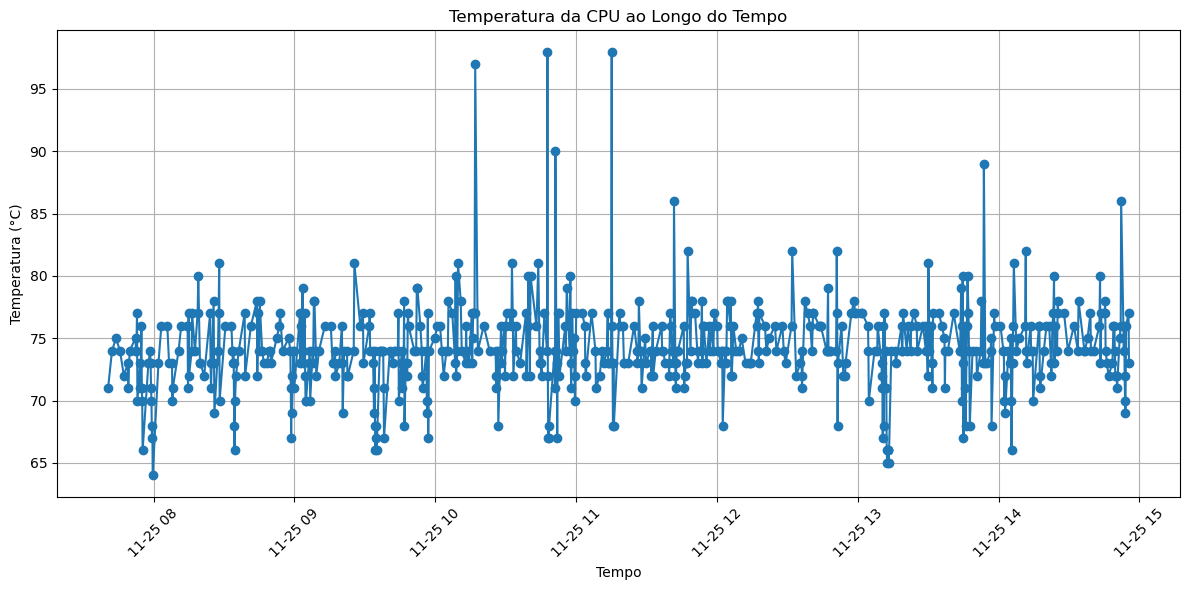

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Ler o arquivo CSV
df = pd.read_csv('exp01-multiprocessing/result_exp_multiprocessing_20251125_073926.csv') # Com Turbo Bost

# 2. Converter Timestamp para datetime
# O pandas lê datas como texto (object) por padrão. 
# Precisamos converter para ele entender a ordem cronológica no gráfico.
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# 3. Criar o gráfico
plt.figure(figsize=(12, 6))

# Opção A: Plot simples (Linha única)
plt.plot(df['Timestamp'], df['Temp°C'], marker='o')

# Opção B: Plot agrupado por Governador (Recomendado se tiver governadores misturados)
#governors = df['Executed_Governor'].unique()
#for gov in governors:
#    subset = df[df['Executed_Governor'] == gov]
#    plt.plot(subset['Timestamp'], subset['Temp°C'], marker='o', label=gov)

plt.title('Temperatura da CPU ao Longo do Tempo')
plt.xlabel('Tempo')
plt.ylabel('Temperatura (°C)')
#plt.legend()
plt.grid(True)
plt.xticks(rotation=45) # Inclina as datas para facilitar a leitura
plt.tight_layout()
plt.show()

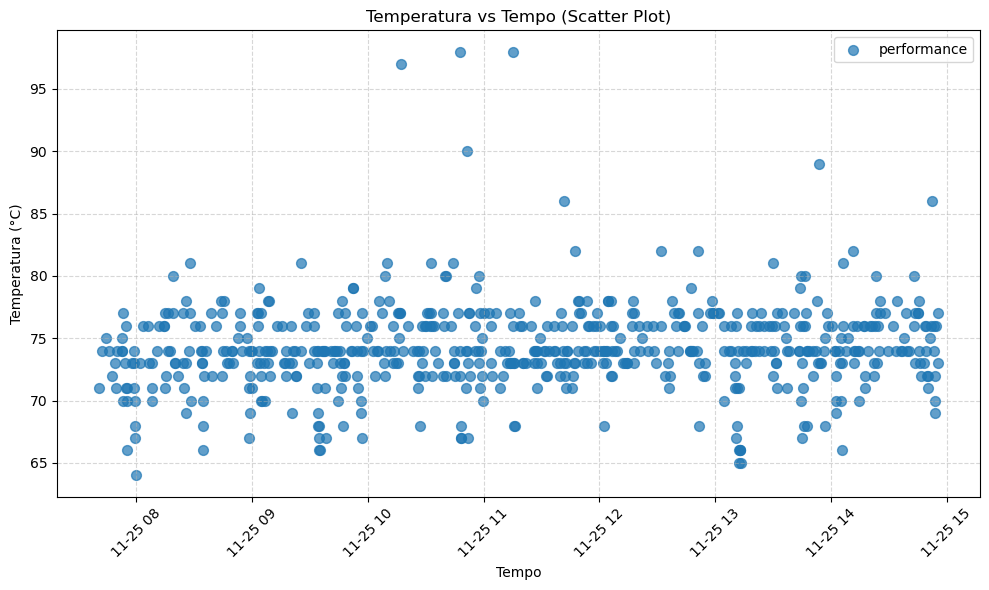

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Preparação 
df = pd.read_csv('exp01-multiprocessing/result_exp_multiprocessing_20251125_073926.csv') # Com Turbo Bost
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

plt.figure(figsize=(10, 6))

governors = df['Executed_Governor'].unique()

for gov in governors:
    subset = df[df['Executed_Governor'] == gov]
    
    plt.scatter(
        subset['Timestamp'], 
        subset['Temp°C'], 
        label=gov,
        alpha=0.7,  # Deixa o ponto meio transparente (bom se tiver muitos pontos amontoados)
        s=50        # Tamanho do ponto (size)
    )

plt.title('Temperatura vs Tempo (Scatter Plot)')
plt.xlabel('Tempo')
plt.ylabel('Temperatura (°C)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

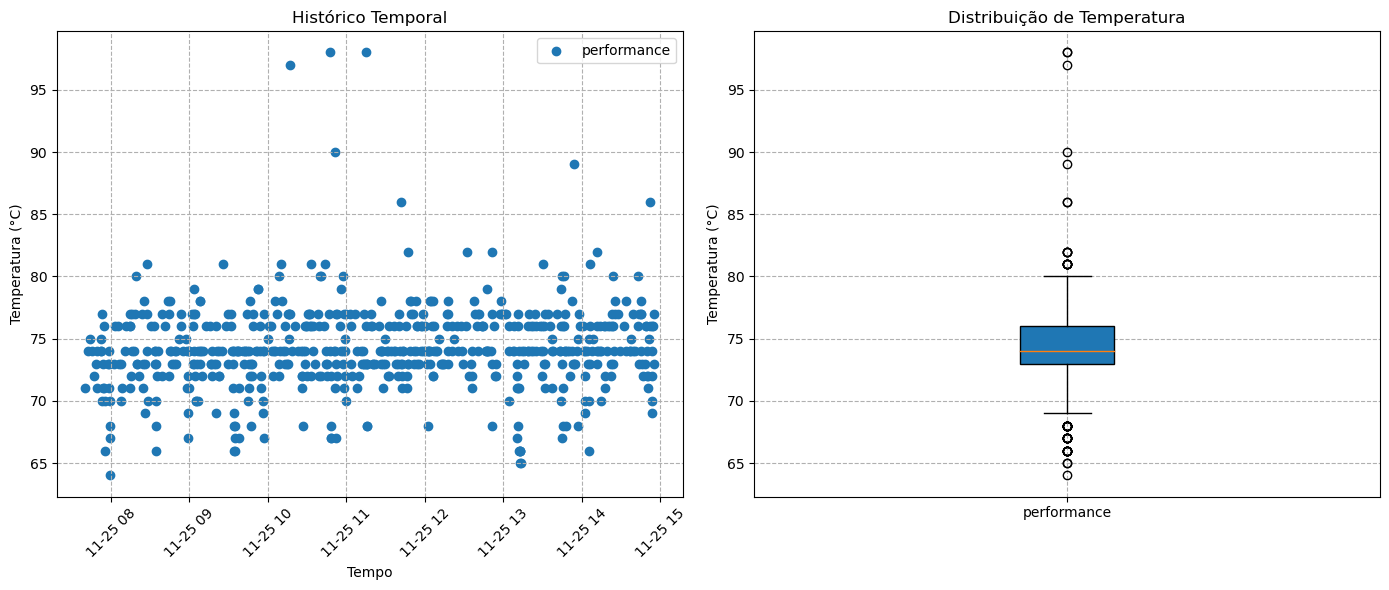

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# Ler e preparar dados
df = pd.read_csv('exp01-multiprocessing/result_exp_multiprocessing_20251125_073926.csv') # Com Turbo Bost
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Criar uma figura com 2 subgráficos (ax1 e ax2)
# figsize=(largura, altura)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- Gráfico 1: Scatter (Esquerda) ---
governors = df['Executed_Governor'].unique()
for gov in governors:
    subset = df[df['Executed_Governor'] == gov]
    ax1.scatter(subset['Timestamp'], subset['Temp°C'], label=gov)

ax1.set_title('Histórico Temporal')
ax1.set_xlabel('Tempo')
ax1.set_ylabel('Temperatura (°C)')
ax1.legend()
ax1.grid(True, linestyle='--')
ax1.tick_params(axis='x', rotation=45) # Rotaciona datas

# --- Gráfico 2: Box Plot (Direita) ---
# O boxplot do matplotlib pede uma lista de listas/arrays
data_by_gov = [df[df['Executed_Governor'] == gov]['Temp°C'] for gov in governors]

ax2.boxplot(data_by_gov, labels=governors, patch_artist=True)
ax2.set_title('Distribuição de Temperatura')
ax2.set_ylabel('Temperatura (°C)')
ax2.grid(True, linestyle='--')

plt.tight_layout() # Ajusta os espaçamentos automaticamente
plt.show()

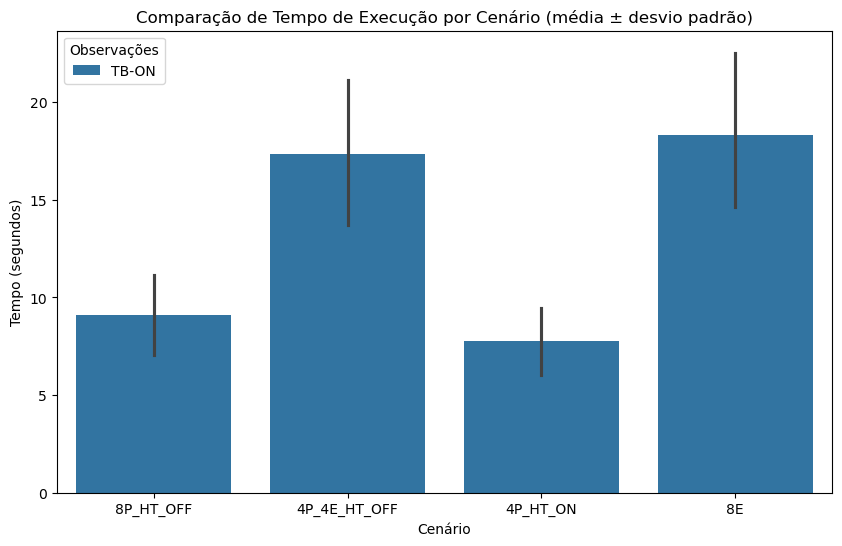

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Supondo que seus arquivos estejam em CSV
df1 = pd.read_csv('exp01-multiprocessing/result_exp_multiprocessing_20251124_133408.csv') # Com Turbo Bost
df1['Dataset'] = 'TB-ON'

plt.figure(figsize=(10,6))
sns.barplot(
    x='CPU_Set_Name',
    y='Time_sec',
    hue='Dataset',
    data=df1,
    estimator='mean'       # calcula a média automaticamente
    #errorbar='sd'           # mostra desvio padrão
)
plt.title('Comparação de Tempo de Execução por Cenário (média ± desvio padrão)')
plt.ylabel('Tempo (segundos)')
plt.xlabel('Cenário')
plt.legend(title='Observações')

# Salvar como PDF
#plt.savefig('grafico_time_sec.pdf', format='pdf', bbox_inches='tight')

# Salvar como PNG
plt.savefig('grafico_time_sec.png', format='png', dpi=300, bbox_inches='tight')

plt.show()

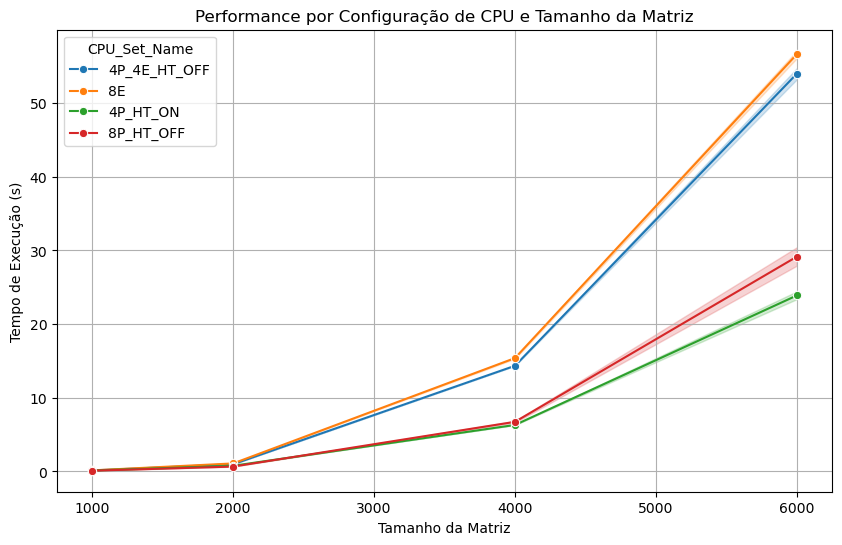

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Supondo que 'df' seja o seu DataFrame criado pelo script
df = pd.read_csv('exp01-multiprocessing/result_exp_multiprocessing_20251124_133408.csv') # Com Turbo Bost
df['Dataset'] = 'TB-ON'

# 1. Garantir que a coluna Matrix_Size é numérica para ordenar corretamente
df['Matrix_Size'] = pd.to_numeric(df['Matrix_Size'])

# 2. Ordenar o DataFrame pelo tamanho da matriz (requisito: "em ordem")
df = df.sort_values(by='Matrix_Size')

# 3. Configurar o tamanho da figura
plt.figure(figsize=(10, 6))

# 4. Criar o gráfico
# x: O eixo horizontal (Tamanho da Matriz)
# y: O eixo vertical (Tempo)
# hue: O agrupador que define as cores (CPU_Set_Name)
sns.lineplot(
    data=df, 
    x='Matrix_Size', 
    y='Time_sec', 
    hue='CPU_Set_Name', 
    marker='o' # Adiciona marcadores nos pontos exatos
)

# 5. Adicionar títulos e legendas
plt.title('Performance por Configuração de CPU e Tamanho da Matriz')
plt.xlabel('Tamanho da Matriz')
plt.ylabel('Tempo de Execução (s)')
plt.grid(True) # Adiciona uma grade para facilitar a leitura

# Salvar ou mostrar
plt.savefig('grafico_matrix.png')
plt.show()

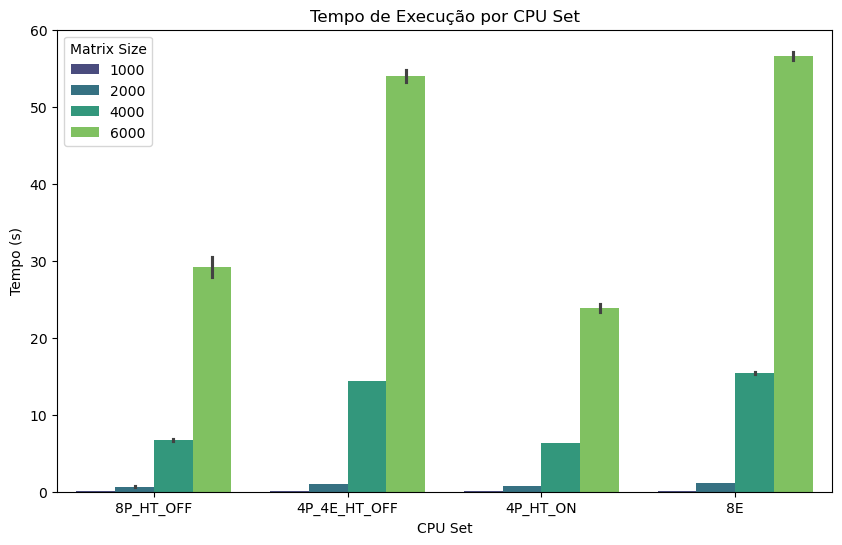

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('exp01-multiprocessing/result_exp_multiprocessing_20251124_133408.csv') # Com Turbo Bost
df['Dataset'] = 'TB-ON'

# 1. Garanta que a coluna seja string se quiser cores categóricas
df['Matrix_Size'] = df['Matrix_Size'].astype(str)

# 2. Crie a lista de ordem explicitamente
# Pegamos os valores únicos, convertemos para int para ordenar, e voltamos para str
order_matrix = sorted(df['Matrix_Size'].unique(), key=lambda x: int(x))

plt.figure(figsize=(10, 6))

sns.barplot(
    data=df,
    x='CPU_Set_Name',
    y='Time_sec',
    hue='Matrix_Size',
    hue_order=order_matrix,  # <--- O SEGREDO ESTÁ AQUI
    palette='viridis'
)

plt.title('Tempo de Execução por CPU Set')
plt.ylabel('Tempo (s)')
plt.xlabel('CPU Set')
plt.legend(title='Matrix Size')

plt.show()

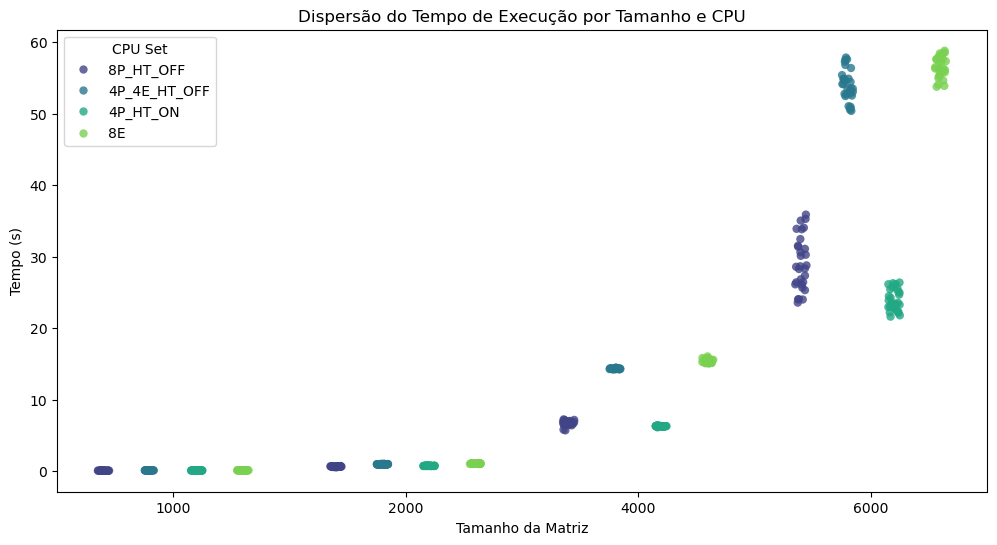

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('exp01-multiprocessing/result_exp_multiprocessing_20251124_133408.csv') # Com Turbo Bost
df['Dataset'] = 'TB-ON'

# Converter para string é importante para o agrupamento categórico funcionar bem
df['Matrix_Size'] = df['Matrix_Size'].astype(str)
order_matrix = sorted(df['Matrix_Size'].unique(), key=lambda x: int(x))

plt.figure(figsize=(12, 6))

sns.stripplot(
    data=df,
    x='Matrix_Size',
    y='Time_sec',
    hue='CPU_Set_Name',
    order=order_matrix,  # Garante a ordem 1000 -> 4000
    dodge=True,          # <--- ISSO É FUNDAMENTAL: Separa as cores lado a lado
    jitter=True,         # Espalha levemente os pontos para não ficarem amontoados
    palette='viridis',
    size=6,              # Tamanho dos pontos
    alpha=0.8            # Transparência para ver sobreposições
)

plt.title('Dispersão do Tempo de Execução por Tamanho e CPU')
plt.ylabel('Tempo (s)')
plt.xlabel('Tamanho da Matriz')
plt.legend(title='CPU Set')

plt.show()

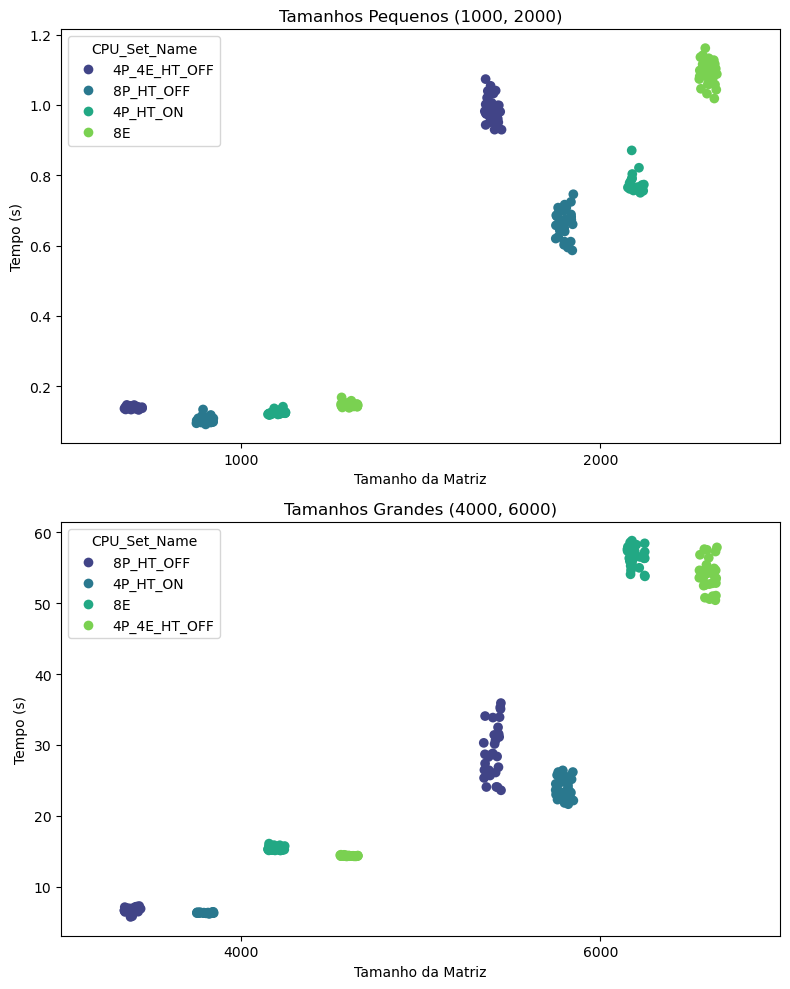

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('exp01-multiprocessing/result_exp_multiprocessing_20251124_133408.csv') # Com Turbo Bost
df['Dataset'] = 'TB-ON'

# Se 'Matrix_Size' for numérico no seu DF, remova as aspas dos números nas listas abaixo.

# 1. Definir os grupos
sizes_small = [1000, 2000]
sizes_large = [4000, 6000]

# 2. Criar uma figura com 2 subplots um sobre o outro nrows=2, ncols=1.
# figsize controla o tamanho total da imagem (largura, altura)
# Aumentamos a altura (10) e diminuímos a largura (8) do figsize.
fig, axes = plt.subplots(2, 1, figsize=(8, 10))

# --- GRÁFICO 1: Matrizes Pequenas (axes[0]) ---
# Filtramos o dataframe apenas com os tamanhos pequenos
df_small = df[df['Matrix_Size'].isin(sizes_small)]

sns.stripplot(
    data=df_small,
    x='Matrix_Size',
    y='Time_sec',
    hue='CPU_Set_Name',
    order=sizes_small,    # Força a ordem e remove categorias vazias do eixo
    dodge=True,
    jitter=True,
    size=7,
    palette='viridis',
    ax=axes[0]            # <--- Manda plotar no quadro da esquerda
)
axes[0].set_title('Tamanhos Pequenos (1000, 2000)')
axes[0].set_ylabel('Tempo (s)')
axes[0].set_xlabel('Tamanho da Matriz')

# --- GRÁFICO 2: Matrizes Grandes (axes[1]) ---
# Filtramos o dataframe apenas com os tamanhos grandes
df_large = df[df['Matrix_Size'].isin(sizes_large)]

sns.stripplot(
    data=df_large,
    x='Matrix_Size',
    y='Time_sec',
    hue='CPU_Set_Name',
    order=sizes_large,
    dodge=True,
    jitter=True,
    size=7,
    palette='viridis',
    ax=axes[1]            # <--- Manda plotar no quadro da direita
)
axes[1].set_title('Tamanhos Grandes (4000, 6000)')
axes[1].set_ylabel('Tempo (s)')
axes[1].set_xlabel('Tamanho da Matriz')

# Ajusta o layout para não sobrepor textos
plt.tight_layout()
plt.show()